This notebook is only to see the catboost regressor of the RNAseq z-score combat (withour ridge)

In [63]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import feature_selection as fs
import pickle

In [67]:
fit=False

In [2]:
eigth_bins = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_SMOTE_SMOTE_8_b.csv")
eigth_bins.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age
0,-0.027196,-0.031684,-0.001005,-0.029161,-0.029152,-0.031145,-0.022870,-0.028542,-0.023569,-0.027138,...,-0.031746,-0.031568,-0.031728,-0.031280,-0.030700,-0.031722,-0.031747,-0.028999,-0.031495,71-72
1,-0.017960,-0.025238,-0.004623,-0.023480,-0.023654,-0.024793,-0.019915,-0.022223,-0.020463,-0.022694,...,-0.025233,-0.025066,-0.025206,-0.025120,-0.025112,-0.025200,-0.025239,-0.028055,-0.025034,72-95
2,-0.023509,-0.027209,-0.007440,-0.025756,-0.025439,-0.026228,-0.020806,-0.020602,-0.022891,-0.023687,...,-0.027264,-0.027278,-0.027292,-0.027227,-0.026625,-0.027285,-0.027258,-0.025183,-0.026903,50-65
3,-0.028414,-0.032553,-0.001362,-0.028270,-0.029386,-0.032315,-0.027363,-0.028447,-0.024889,-0.028220,...,-0.032615,-0.032625,-0.032598,-0.032513,-0.031188,-0.032593,-0.032616,-0.029468,-0.032476,71-72
4,-0.025459,-0.030208,-0.001516,-0.026133,-0.027908,-0.029627,-0.020931,-0.025970,-0.022807,-0.024564,...,-0.030213,-0.030210,-0.030236,-0.030152,-0.027916,-0.030232,-0.030207,-0.029553,-0.029378,35-50


In [100]:
ridge_selection = f"/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_feature_selection.csv"
df = gtg.get_df(ridge_selection)# alpha=0.05
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
0.1450134054998397


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/pandas/core/indexes/base.py:945: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*new_inputs, **kwargs)
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


458

In [102]:
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Age")


In [103]:
eigth_bins_filteres = eigth_bins[rnaseq_genes]


In [104]:
del eigth_bins

In [105]:
seq_y_train_cat_a=eigth_bins_filteres["Age"]
seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)

dataset = eigth_bins_filteres.copy()
dataset["Age"]=seq_y_train_a
dataset.head()

,ENSG00000232177.1,ENSG00000189058.8,ENSG00000249072.1,ENSG00000127720.7,ENSG00000270388.1,ENSG00000255633.5,ENSG00000233494.1,ENSG00000199455.1,ENSG00000185885.15,ENSG00000255823.4,...,ENSG00000185915.5,ENSG00000108946.14,ENSG00000197872.11,ENSG00000140795.12,ENSG00000133315.10,ENSG00000112562.18,ENSG00000146574.15,ENSG00000202430.1,ENSG00000107959.15,Age
0,-0.016213,-0.020295,-0.016214,-0.019147,-0.021743,-0.031310,-0.025816,-0.025858,-0.021152,31.350936,...,-0.019094,0.057033,-0.030232,0.001262,0.041741,-0.014235,-0.012814,-0.013062,-0.013178,73.0
1,-0.015271,-0.016304,-0.005234,-0.014237,-0.021156,-0.025476,-0.021692,-0.022962,-0.023206,36.070727,...,-0.015044,0.041878,-0.023206,-0.005008,0.027347,-0.010038,-0.011351,-0.015438,-0.011208,83.0
2,-0.028982,-0.023402,-0.019149,-0.025408,-0.033451,-0.027578,-0.020881,-0.031144,-0.024466,24.154308,...,-0.015861,0.033126,-0.025242,-0.010160,0.016921,-0.013382,-0.007344,0.039108,-0.014805,57.0
3,-0.016746,-0.021343,-0.019233,-0.017358,-0.022273,-0.032175,-0.029540,-0.026468,-0.022312,31.207744,...,-0.014214,0.059248,-0.030027,0.002054,0.032710,-0.012640,-0.007675,-0.013548,-0.009288,70.0
4,0.047836,-0.005859,-0.015909,-0.002875,0.138452,-0.030651,-0.015633,-0.033927,-0.027535,33.911305,...,-0.017523,0.061202,-0.022081,-0.009166,0.019674,-0.014194,-0.005409,-0.041880,-0.004569,41.0


In [107]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=0.2)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate rmse
        rmse = mean_squared_error(self.y_test, y_pred, squared=False)
        return rmse


In [108]:

optimize = optimize(train_data = dataset, n_trials=20)
params = optimize.optimize()
params

[I 2024-05-14 16:30:49,170] A new study created in memory with name: no-name-dd6289b2-9423-48cf-87e4-a820a71ba2df
/tmp/ipykernel_104946/2534274487.py:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/optuna/trial/_trial.py:676: RuntimeWarning: Inconsistent parameter values for distribution with name "iterations"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 50, 'high': 1000}
  warnings.warn(
/tmp/ipykernel

In [114]:
params = {'iterations': 2000, 'learning_rate': 0.0057754728847108075, 'depth': 4, 'l2_leaf_reg': 1.4995313057538833, 'random_strength': 3.6144926272336773, 'min_data_in_leaf': 33, 'score_function': 'Cosine', 'penalties_coefficient': 7.492437722110218, 'model_shrink_rate': 0.0036095159058368662}

In [109]:
fit=True

In [115]:
X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(**params) 

# Fit the model
if fit:
    seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 21.3042778	test: 20.4364972	best: 20.4364972 (0)	total: 13.1ms	remaining: 26.2s
1:	learn: 21.2782029	test: 20.4269542	best: 20.4269542 (1)	total: 40.2ms	remaining: 40.1s
2:	learn: 21.2559842	test: 20.3998819	best: 20.3998819 (2)	total: 66.9ms	remaining: 44.5s
3:	learn: 21.2336566	test: 20.3704875	best: 20.3704875 (3)	total: 83.1ms	remaining: 41.5s
4:	learn: 21.2066364	test: 20.3356611	best: 20.3356611 (4)	total: 97.9ms	remaining: 39.1s
5:	learn: 21.1867679	test: 20.3087296	best: 20.3087296 (5)	total: 120ms	remaining: 40s
6:	learn: 21.1612136	test: 20.2911736	best: 20.2911736 (6)	total: 147ms	remaining: 41.8s
7:	learn: 21.1380300	test: 20.2553916	best: 20.2553916 (7)	total: 193ms	remaining: 48.1s
8:	learn: 21.1128910	test: 20.2329454	best: 20.2329454 (8)	total: 219ms	remaining: 48.4s
9:	learn: 21.0889860	test: 20.1914024	best: 20.1914024 (9)	total: 251ms	remaining: 50s
10:	learn: 21.0580098	test: 20.1605911	best: 20.1605911 (10)	total: 273ms	remaining: 49.4s
11:	learn: 21.0386

In [116]:
if fit:
    # Specify the file path where you want to save the pickle file
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_8_Ridge_seq_regressor.pkl'

    # Save the seq_regressor variable in the pickle file
    with open(file_path, 'wb') as f:
        pickle.dump(seq_regressor, f)
else:

    # Specify the file path where the pickle file is located
    file_path = '/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/models/RNAs_z_Combat_8_Ridge_seq_regressor.pkl'

    # Load the seq_regressor object from the pickle file
    with open(file_path, 'rb') as f:
        seq_regressor = pickle.load(f)

    # Now you can use the seq_regressor object in your code


In [117]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse

78.47310800398373

In [118]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate R2
r2 = r2_score(y_test, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 78.47310800398373
RMSE: 8.858504840207727
MAE: 5.961694857900543
R2: 0.8128830295237033


In [119]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(y_test, age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 3},
 {'label': '26-35', 'range': (26, 35), 'count': 3},
 {'label': '35-50', 'range': (35, 50), 'count': 4},
 {'label': '50-65', 'range': (50, 65), 'count': 3},
 {'label': '65-71', 'range': (65, 71), 'count': 3},
 {'label': '71-72', 'range': (71, 72), 'count': 1},
 {'label': '72-95', 'range': (72, 95), 'count': 6}]

In [120]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[2, 0, 1, 0, 0, 0, 0],
       [0, 1, 2, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 0],
       [0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 3, 0, 0],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 2, 3, 0, 1]])

In [121]:
seq_auc=accuracy_score(c_y_test.round(0), c_y_pred.round(0))
seq_auc

0.6086956521739131

0.043478260869565216

In [122]:
y_test

127    68.0
294    70.0
61     40.0
179    33.0
241    59.0
19     73.0
142    22.0
126    72.0
190    31.0
259    60.0
65     30.0
311    83.0
215    40.0
276    70.0
135    71.0
168    22.0
54     20.0
84     72.0
299    83.0
235    60.0
199    38.0
30     42.0
112    72.0
Name: Age, dtype: float64

In [123]:
seq_results

,Actual,Predicted
127,68.0,65.623853
294,70.0,69.329208
61,40.0,45.259073
179,33.0,34.927311
241,59.0,56.129805
19,73.0,65.702094
142,22.0,23.503701
126,72.0,63.303384
190,31.0,35.411629
259,60.0,60.024578


/tmp/ipykernel_104946/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


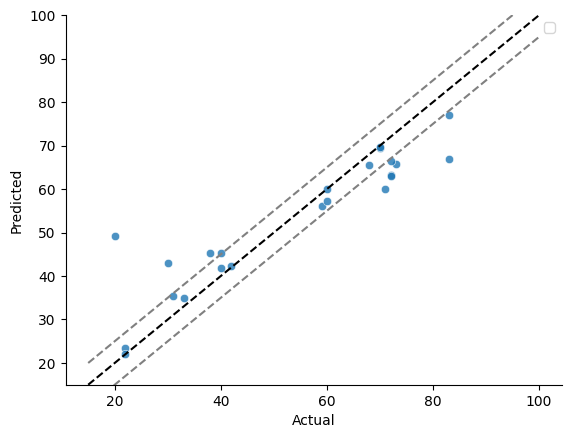

In [124]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [125]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[2, 0, 1, 0, 0, 0, 0],
       [0, 1, 2, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 0],
       [0, 0, 0, 3, 0, 0, 0],
       [0, 0, 0, 0, 3, 0, 0],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 2, 3, 0, 1]])

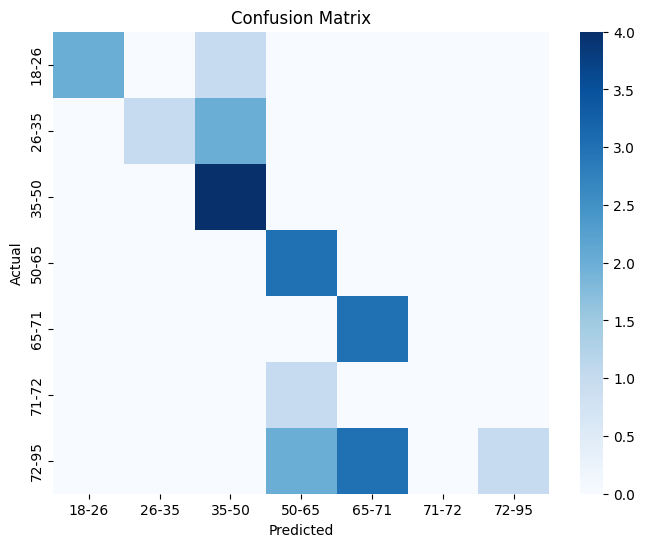

In [126]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
eigth_bins_test = pd.read_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/SMOTE/RNAs_z_Combat_test.csv")
eigth_bins_test.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Age,Sample,Experiment
0,-0.022199,-0.024329,-0.003773,-0.024342,-0.023168,-0.023118,-0.019650,-0.021929,-0.022809,-0.023842,...,-0.024369,-0.024371,-0.023585,-0.024358,-0.024395,-0.023025,-0.024297,24.0,SRR12604218,GSE157585
1,-0.020040,-0.021205,-0.004026,-0.020311,-0.020125,-0.021354,-0.018610,-0.019685,-0.018587,-0.019628,...,-0.021322,-0.021221,-0.021747,-0.021319,-0.021378,-0.022606,-0.021146,18.0,SRR13759023,GSE167186
2,-0.025774,-0.027019,-0.004049,-0.024784,-0.023620,-0.026312,-0.020406,-0.022771,-0.020741,-0.023250,...,-0.026922,-0.026842,-0.026598,-0.026915,-0.026944,-0.020781,-0.026752,23.0,SRR13759025,GSE167186
3,-0.026286,-0.031094,0.001080,-0.029463,-0.029558,-0.029211,-0.020112,-0.026330,-0.020258,-0.028490,...,-0.030938,-0.030771,-0.028873,-0.030937,-0.030940,-0.030323,-0.030942,26.4,SRR1555206,GSE60590
4,-0.021510,-0.026220,0.001219,-0.022533,-0.023448,-0.025671,-0.014182,-0.018851,-0.015137,-0.019720,...,-0.026261,-0.026039,-0.026443,-0.026252,-0.026286,-0.024934,-0.026092,71.0,SRR12604184,GSE157585


In [127]:
age_ranges_list=[18, 26, 35, 50, 65, 71,72, 95]
age_ranges = fs.get_age_distribution(eigth_bins_test["Age"], age_ranges=age_ranges_list)
age_ranges

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [52]:
X_test_untoached = eigth_bins_test.drop(columns=["Age"])
X_test_untoached.drop(columns=["Experiment", "Sample"], inplace=True)
y_test_untoached = eigth_bins_test["Age"]
seq_z_test = eigth_bins_test["Experiment"]

In [53]:
seq_z_test = pd.DataFrame(seq_z_test)
seq_z_test.columns = ["Experiment"]

In [128]:
# Make predictions
y_pred = seq_regressor.predict(X_test_untoached)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test_untoached, y_pred)
seq_results = pd.DataFrame({'Actual': y_test_untoached, 'Predicted': y_pred})
seq_mse

181.2473660119169

/tmp/ipykernel_104946/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


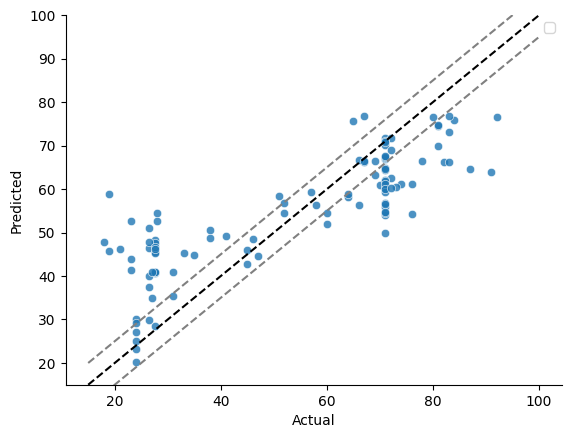

In [129]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

     Actual  Predicted Experiment
0      24.0  23.264524  GSE157585
1      18.0  47.853854  GSE167186
2      23.0  43.814920  GSE167186
3      26.4  46.484862   GSE60590
4      71.0  71.753491  GSE157585
..      ...        ...        ...
103    71.0  64.498164  GSE157585
104    23.0  52.566197  GSE167186
105    72.0  60.222541  GSE164471
106    71.0  67.648163  GSE157585
107    71.0  49.991089  GSE167186

[108 rows x 3 columns]


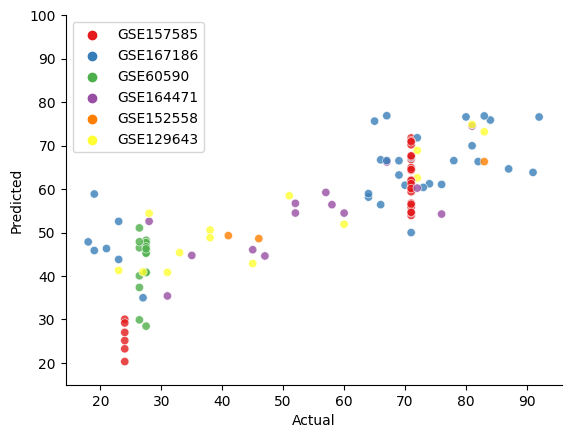

In [130]:
m.plot_results(results=seq_results, labels=seq_z_test)

[{'label': '18-26', 'range': (18, 26), 'count': 13},
 {'label': '26-35', 'range': (26, 35), 'count': 23},
 {'label': '35-50', 'range': (35, 50), 'count': 8},
 {'label': '50-65', 'range': (50, 65), 'count': 9},
 {'label': '65-71', 'range': (65, 71), 'count': 9},
 {'label': '71-72', 'range': (71, 72), 'count': 25},
 {'label': '72-95', 'range': (72, 95), 'count': 21}]

In [131]:
c_y_test = pd.Series(y_test_untoached).apply(lambda x: divide.assign_age_group(x, age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 3,  3,  5,  2,  0,  0,  0],
       [ 0,  3, 17,  3,  0,  0,  0],
       [ 0,  0,  7,  1,  0,  0,  0],
       [ 0,  0,  0,  9,  0,  0,  0],
       [ 0,  0,  0,  3,  4,  0,  2],
       [ 0,  0,  1, 15,  7,  2,  0],
       [ 0,  0,  0,  8,  5,  1,  7]])

In [132]:
acu = accuracy_score(c_y_test, c_y_pred)
acu

0.32407407407407407

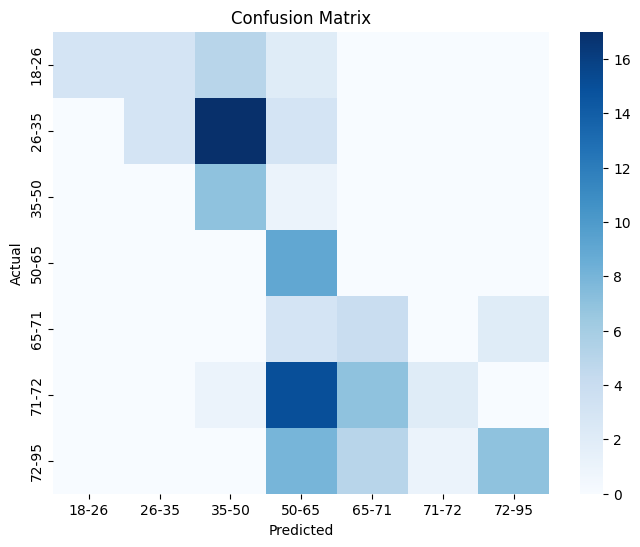

In [133]:
x_labels = [age['label'] for age in age_ranges]
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=x_labels, yticklabels=x_labels, fmt='d', annot=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [134]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
import numpy as np

# Calculate AUC
# Assuming y_test and y_pred are appropriate for AUC calculation (e.g., binary classification)
# auc = roc_auc_score(y_test, y_pred)

# Calculate MSE
mse = mean_squared_error(y_test_untoached, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate MAE
mae = mean_absolute_error(y_test_untoached, y_pred)

# Calculate R2
r2 = r2_score(y_test_untoached, y_pred)

print("Metrics:")
# print("AUC:", auc)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


Metrics:
MSE: 181.2473660119169
RMSE: 13.462814193619286
MAE: 10.743990879542158
R2: 0.6379809406596709


In [135]:
explainer = shap.Explainer(seq_regressor)
shap_values = explainer.shap_values(X_test)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=X_test.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
ENSG00000101892.11,6.316576
ENSG00000277654.5,2.835333
ENSG00000127241.16,2.766827
ENSG00000171055.14,1.780384
ENSG00000170873.18,1.773981
...,...
ENSG00000211691.2,0.011342
ENSG00000200587.1,0.010942
ENSG00000198700.9,0.010505
ENSG00000091732.15,0.004094


In [138]:
feature_imporance_df.head(50)

,importance
ENSG00000101892.11,6.316576
ENSG00000277654.5,2.835333
ENSG00000127241.16,2.766827
ENSG00000171055.14,1.780384
ENSG00000170873.18,1.773981
ENSG00000137700.17,1.738217
ENSG00000177548.12,1.672164
ENSG00000123095.5,1.341633
ENSG00000111640.14,1.208492
ENSG00000127184.12,1.164396


In [140]:
gene_names = [
("ENSG00000101892.11","ATP1B4"),
("ENSG00000201766.1","RNA5SP302"),
("ENSG00000127241.16","MASP1"),
("ENSG00000277654.5","AC087633.2"),
("ENSG00000145949.10","MYLK4"),
("ENSG00000171055.14","FEZ2"),
("ENSG00000198712.1","MT-CO2"),
("ENSG00000164104.11","HMGB2"),
("ENSG00000172399.5","MYOZ2"),
("ENSG00000177548.12","RABEP2"),
("ENSG00000089101.17","CFAP61"),
("ENSG00000003989.17","SLC7A2"),
("ENSG00000137700.17","SLC37A4"),
("ENSG00000174227.15","PIGG"),
("ENSG00000133020.4","MYH8"),
("ENSG00000252262.1","RNA5SP61"),
("ENSG00000234441.1","AC105272.1"),
("ENSG00000247627.2","MTND4P12"),
("ENSG00000100568.10","VTI1B"),
("ENSG00000237973.1","MTCO1P12"),
("ENSG00000170873.18","MTSS1"),
("ENSG00000082397.17"	,"EPB41L3"),
("ENSG00000111640.14"	,"GAPDH")
]

for gene_id, gene_name in gene_names:
    if gene_id in X_test.columns:
        X_test.rename(columns={gene_id: gene_name}, inplace=True)


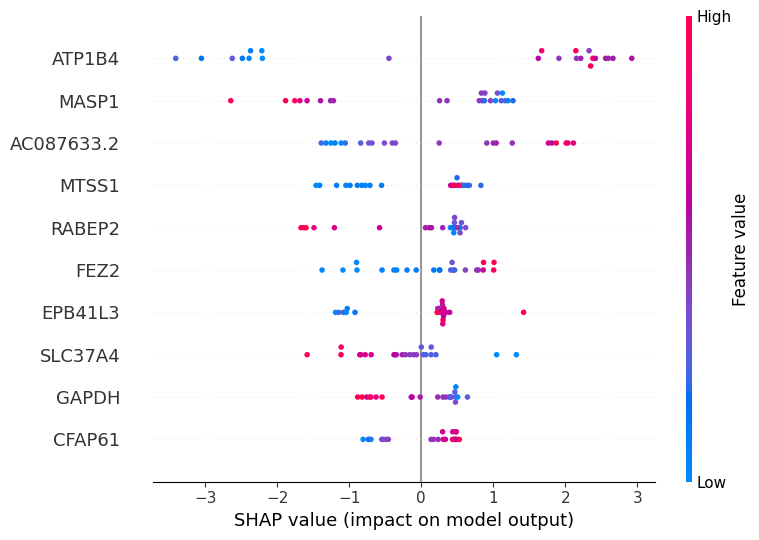

In [141]:
shap.summary_plot(shap_values, X_test, max_display=10)


In [142]:
mcc = matthews_corrcoef(c_y_test, c_y_pred)
mcc

0.28201072184274983